#Import Libraries and Download Data

In [55]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

In [56]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    plt.title('y = ' + str(data_sample[1]))
    plt.show()

In [57]:
#Downloaded MNIST training data and display
train_dataset=dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
print("Print the training dataset: \n", train_dataset)

Print the training dataset: 
 Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [58]:
#Downloaded MNIST validation data and display
validation_dataset = dsets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)
print("Print the validation dataset:\n ", validation_dataset)

Print the validation dataset:
  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


Image and label


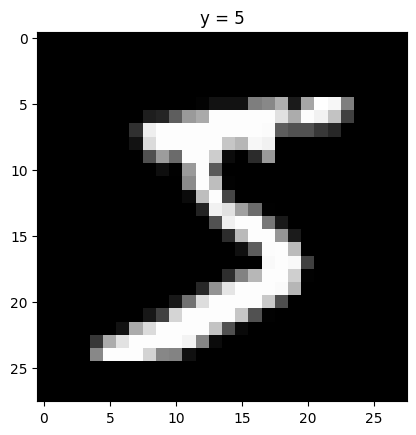

In [59]:
#Display the first image and its corresponding label

print("Image and label")
show_data(train_dataset[0])

In [60]:
print("Just label: ", train_dataset[0][1])

Just label:  5


#Create Model

In [61]:
#Create neural network with one hidden layer
#Architecture: linear->ReLu->Linear
class Neural_Network(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Neural_Network, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [62]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [63]:
#input and output dimensions
input_dim=28*28
output_dim=10

In [64]:
hidden_size = 128
model = Neural_Network(input_dim, hidden_size, output_dim)

In [65]:
print("Print the model:\n ", model)

Print the model:
  Neural_Network(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [66]:
print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([128, 784])
b:  torch.Size([128])


In [67]:
#Reshape input images into (batch_size, 784) for the linear layer
X=train_dataset[0][0]
print(X.shape)
X=X.view(-1,28*28)
print(X.shape)
model(X)

torch.Size([1, 28, 28])
torch.Size([1, 784])


tensor([[-0.0032,  0.1410, -0.0712,  0.0220,  0.0577,  0.0868,  0.0539,  0.0214,
          0.0158, -0.0933]], grad_fn=<AddmmBackward0>)

#Train Model

In [68]:
#Set learning rate for optimizer
learning_rate=0.1
#Use SDG optimizer with momentum
optimizer=torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
#Define loss function
criterion=nn.CrossEntropyLoss()
train_loader=torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader=torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

In [69]:
#number of times we train the entire dataset
epochs=20
loss_list=[]
accuracy_list=[]
test=len(validation_dataset)

def train_model(epochs):
  for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    for x,y in train_loader:
      #Reset gradient
      optimizer.zero_grad()
      #Flatten image and pass through the model
      z=model(x.view(-1,28*28))
      #Calcualte loss
      loss=criterion(z,y)
      #Backpropogate
      loss.backward()
      #Updates weights
      optimizer.step()

    #Evaluate on validation set

    #Switch to evaluation mode
    model.eval()
    correct=0
    with torch.no_grad():
      for a, b in validation_loader:
        z=model(a.view(-1,28*28))
        _,yhat=torch.max(z.data, 1)
        correct+=(yhat==b).sum().item()
    #Compute and append accuracy and loss to respective lists
    accuracy=correct/test
    loss_list.append(loss.item())
    accuracy_list.append(accuracy)
    #Switch to training mode
    model.train()
train_model(epochs)

Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20


#Model Performance

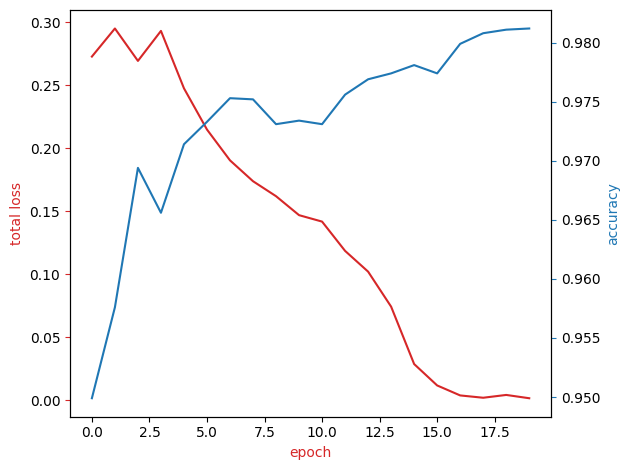

In [70]:
#Plot training loss
fig, ax1=plt.subplots()
color='tab:red'
ax1.plot(loss_list, color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

#Plot accuracy
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

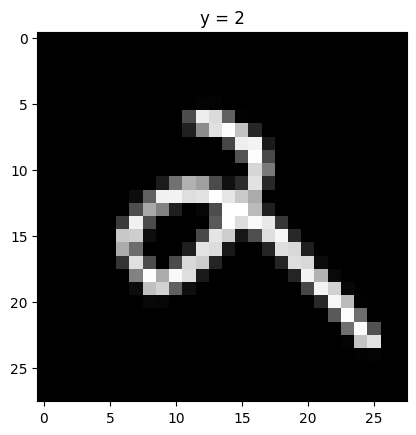

yhat: tensor([5])
probability of class  0.9668235778808594


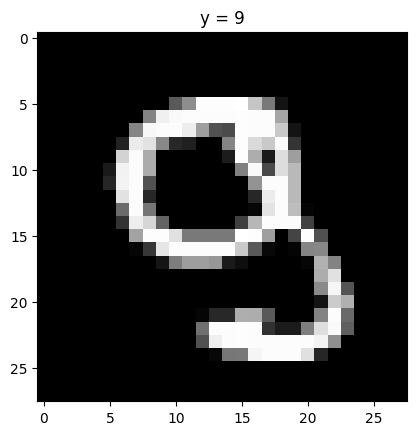

yhat: tensor([8])
probability of class  0.6790350675582886


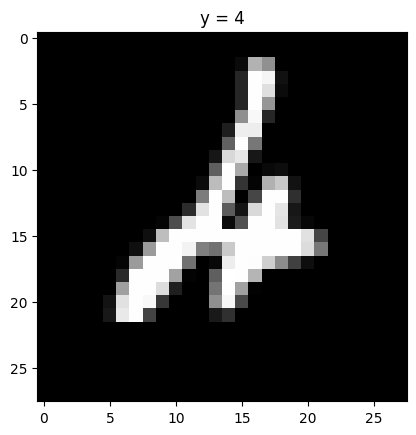

yhat: tensor([2])
probability of class  0.9994379878044128


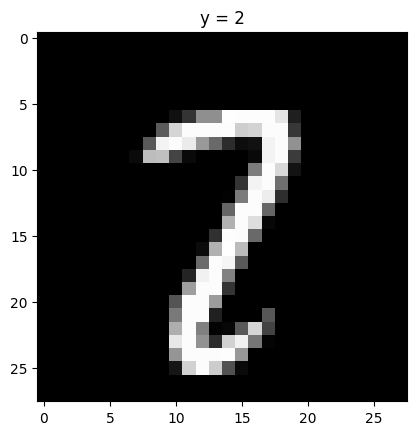

yhat: tensor([7])
probability of class  0.9963239431381226


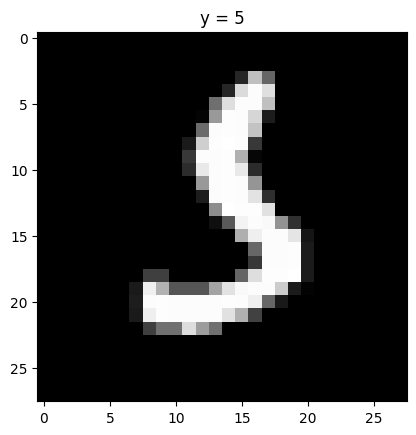

yhat: tensor([3])
probability of class  0.9998335838317871


In [71]:
#Misclassified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

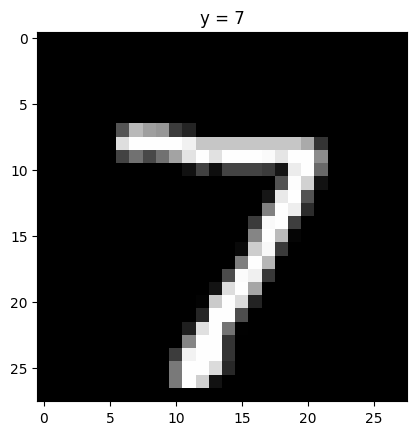

yhat: tensor([7])
probability of class  1.0


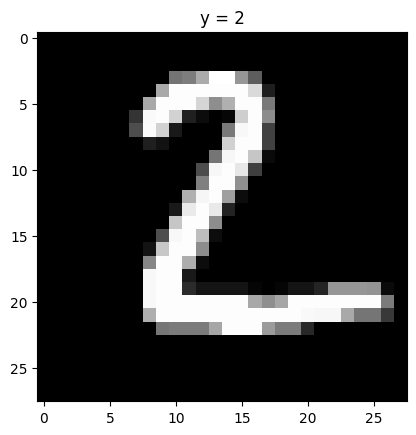

yhat: tensor([2])
probability of class  1.0


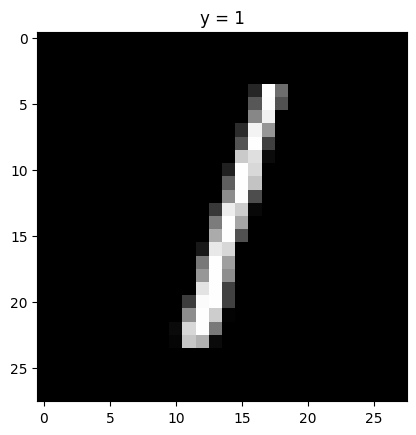

yhat: tensor([1])
probability of class  0.9999895095825195


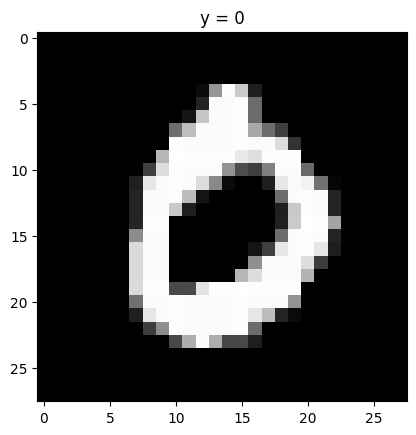

yhat: tensor([0])
probability of class  1.0


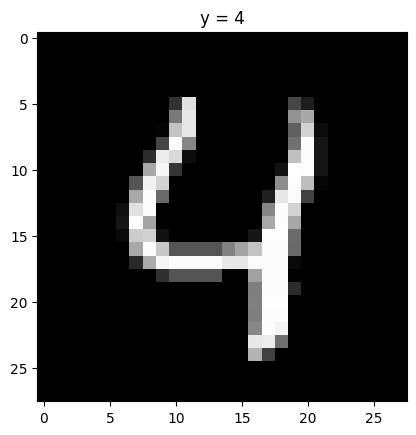

yhat: tensor([4])
probability of class  1.0


In [72]:
#Correctly classified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat == y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

In [73]:
#Model accuracy
accuracy_list[-1]

0.9812